In [69]:
import json
# Auto reloads .py modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
from typing import Optional
from dotenv import load_dotenv
load_dotenv()
import os
import logging as logger
from openai import OpenAI
from app.services.azure_embedding_service import AzureEmbeddingService
from app.to_remove.langchain_rag_service import LangchainRAGService
from app.services.vector_db_service import ChromaDBService
from typing import List
import base64
from tqdm import tqdm

logger.getLogger().setLevel(logger.WARN)


In [71]:

def create_chroma_db() -> ChromaDBService:
    """Creates a ChromaDB instance for vector storage."""
    chroma_db = ChromaDBService(
        persist_directory="./chroma.db",
    )
    logger.info("ChromaDBService initialized.")
    return chroma_db

def create_embeddings_client() -> AzureEmbeddingService:
    """Creates an Azure OpenAI client for embeddings."""
    endpoint = os.getenv("AZURE_EMBEDDINGS_ENDPOINT")
    api_key = os.getenv("AZURE_EMBEDDINGS_API_KEY")
    deployment = os.getenv("AZURE_EMBEDDINGS_DEPLOYMENT")

    if not endpoint or not api_key or not deployment:
        raise ValueError("Missing required environment variables for Azure Embeddings client.")

    try:
        client = AzureEmbeddingService(
            azure_embedding_endpoint=endpoint,
            azure_embedding_key=api_key,
            azure_embedding_model=deployment,
        )
        logger.info("EmbeddingsClient initialized successfully.")
        return client
    except Exception as e:
        logger.error(f"Failed to initialize EmbeddingsClient: {e}", exc_info=True)
        raise

def create_openai_client() -> Optional[OpenAI]:
    """Creates an AzureOpenAI client instance based on environment variables."""
    api_key = os.getenv("OPENAI_CHAT_API_KEY")

    if not api_key:
        raise ValueError("Missing required environment variables for Azure OpenAI client.")

    try:
        client = OpenAI(
            api_key=api_key,
        )
        return client
    except Exception as e:
        logger.error(f"Failed to initialize OpenAI client: {e}", exc_info=True)
        return None

def encode_file(file_path):
    with open(file_path, "rb") as file:
        return base64.b64encode(file.read()).decode('utf-8')


In [72]:
openai_chat_client = create_openai_client()
chroma_db = create_chroma_db()
embeddings_client = create_embeddings_client()
rag = LangchainRAGService(chroma_db, embeddings_client, 500, 50)

## Load Google Drive Files
Since our datasets live in Google Drive, we connect to our data source. This particular method assumes you have [Drive for Desktop](https://dl.google.com/drive-file-stream/GoogleDriveSetup.exe) installed on your computer and you are accessing a local path. For this POC, we focus on assignment 2.

Here we upload "Course Material" for the course into a vector database

In [33]:
course_material = r"I:\.shortcut-targets-by-id\1q2B2T_aTytCWO8SdBLnWpTNEQcPtXqE8\BU MET\cs581_quiz_and_assignment_data\Lecture Material"
# print all course materials
for file in tqdm(os.listdir(course_material)):
    path = course_material + "/" + file
    rag.upload_pdf(file, path)

100%|██████████| 6/6 [05:12<00:00, 52.02s/it] 


Next, I take an image in the course material and try to describe what I'm seeing. Maybe as a student would... Question is, if I run RAG on this prompt, will I get that image back?

In [44]:
res = rag.retrieve(r"""The entire process starts when the patient schedules an appointment.
Then thee patient completes registration and checks-in for their appointment.

This is followed by order entry, results management, medication management, health maintenance, billing an coding, to checkout.

But it doesn't just stop there. Other items like patient education and referral management also play a role.""", 5);

In [45]:
res['ids']

[['Module 2 Lecture Materials.pdf:2:0:image',
  'Module 2 Lecture Materials.pdf:10:0:image',
  'Module 3 Lecture Materials.pdf:9:0:image',
  'Mod 2 HIS & EHR Clinical Functionality-Lecture Slides.pdf_:19:text',
  'Module 1 Lecture Materials.pdf:74:text']]

WOAH! I was only half expecting this to work. This is indeed the exact image I was describing. This proves our approach for multi-modal RAG works! Its also worth noting that the closest text content that was matched is ALSO from Module 2 (where this image is from). This was exactly the behavior I was expecting!

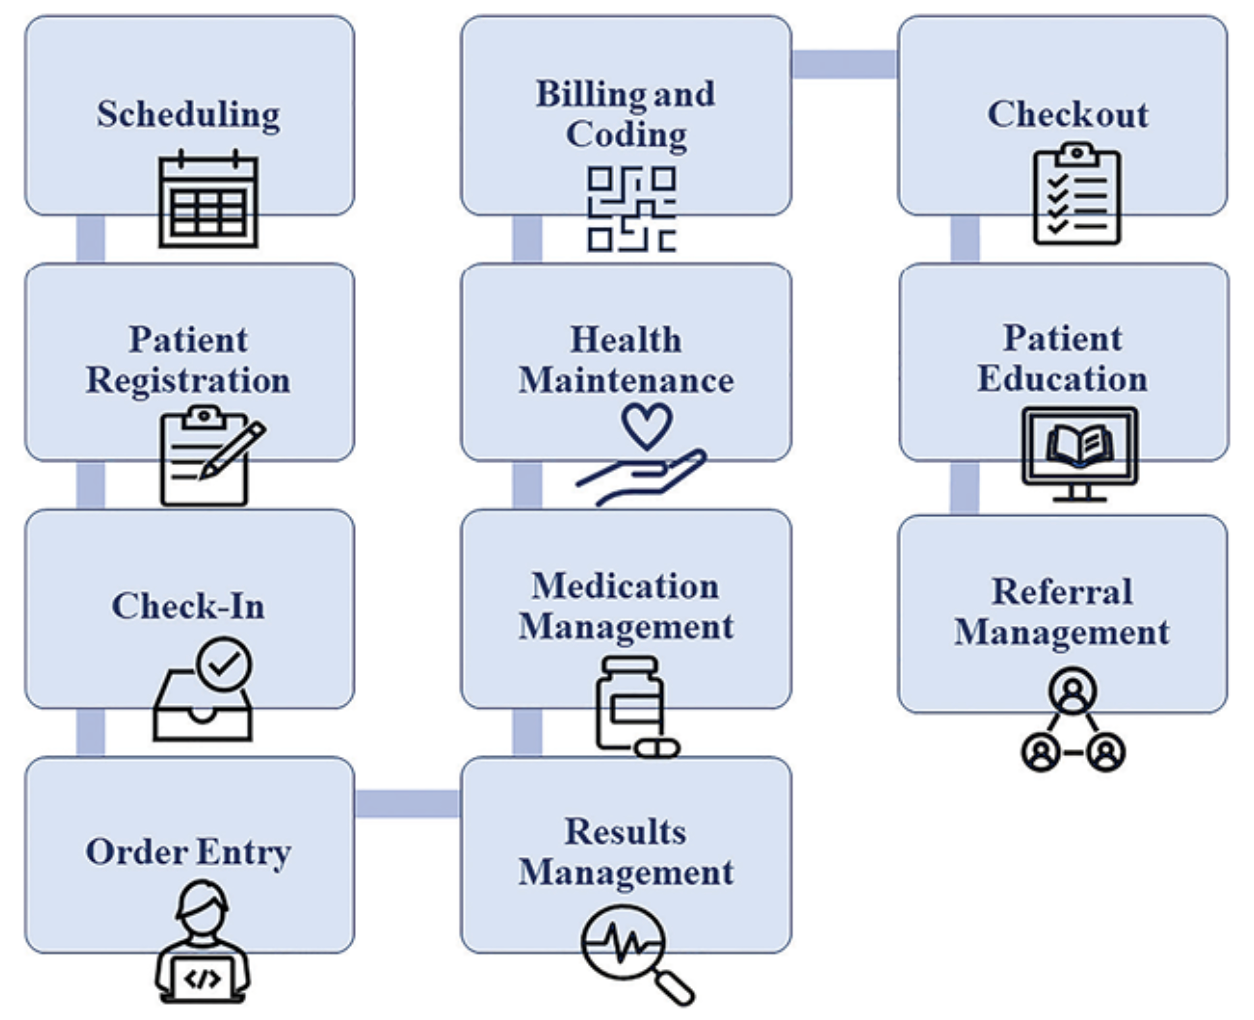

In [58]:
from IPython.display import Image, display
base64_image_data = res['metadatas'][0][0]['data']
image_bytes = base64.b64decode(base64_image_data)
display(Image(data=image_bytes))

But, this is MULTI-MODAL RAG. I am yet to demonstate this also works for text. So now I will go to a random section in the course materials, and summarize what I see. Will RAG find what I was talking about...?

In [59]:
res = rag.retrieve(""" What are some major sources of population health data? They are: Patient surveys, clinical records, claims data, wearable devices, and socioeconomic databases.
""", 5)

In [60]:
res['ids']

[['Module 3 Lecture Materials.pdf:13:text',
  'Module 3 Lecture Materials.pdf:14:text',
  'Module 3 Lecture Materials.pdf:12:text',
  'Module 2 Lecture Materials.pdf:12:text',
  'Module 3 Lecture Materials.pdf:15:text']]

In [66]:
json.loads(res['metadatas'][0][0]['page_map_json'])

{'4': "(diet, exercise), healthcare utilization data (provider visits, medication use), and geographic\n\nlocation; all of which are necessary to understand health trends and disparities within a population and identify\n\nareas for intervention.\n\n\nTherefore, population health data can come from a variety of sources, including:\n\n\n       Patient surveys: A structured method of collecting health data from a sample of the population\n\n       Clinical records: Detailed data on a patient's health history, includ"}

In [67]:
json.loads(res['metadatas'][0][1]['page_map_json'])

{'4': 'ing demographic, diagnoses, laboratory\n\n       results, physician reports, lifestyle, and health status\n\n      Claims data: Data from payers such as healthcare utilization\n\n      Wearable devices: Data collected from wearable devices',
 '5': 'Socioeconomic databases: Data on social determinants of health, such as living conditions, environmental\n\n       data, and economic status\n\n\nImportant considerations when collecting population health data:\n\n\n      Data quality: Ensuring data accuracy and completeness'}

This was indeed the text I was referring to! RAG has now demonstrated that it works both with text inputs and image inputs. This is a huge milestone for our project!

## Accepting PDF Responses
GPT 4o can accept and proccess PDF responses. In fact it is quite good at it.

In [76]:
class StudentResponse:
    rubric_path: str
    submission_path: str
    def __init__(self, rubric_path, submission_path):
        self.rubric_path = rubric_path
        self.submission_path = submission_path

In [77]:
# Initialize list to hold student responses
student_responses: List[StudentResponse] = []
# Relevant material list
relevant_material = r"I:\.shortcut-targets-by-id\1q2B2T_aTytCWO8SdBLnWpTNEQcPtXqE8\BU MET\cs581_quiz_and_assignment_data\Assignment 2 – EHR Functional Requirements Worksheet\Assignment2_relevant_material.pdf"
assignment_requirements = r"I:\.shortcut-targets-by-id\1q2B2T_aTytCWO8SdBLnWpTNEQcPtXqE8\BU MET\cs581_quiz_and_assignment_data\Assignment 2 – EHR Functional Requirements Worksheet\CS581 Assignment 2 HIS Clinical (EHR) Functional Requirements 2025 Spring 1.pdf"

In [78]:
# Define the base directory
base_dir = r"I:\.shortcut-targets-by-id\1q2B2T_aTytCWO8SdBLnWpTNEQcPtXqE8\BU MET\cs581_quiz_and_assignment_data\Assignment 2 – EHR Functional Requirements Worksheet\24fallmetcs581_m1 submissions and rubrics"

# Iterate through student directories
for student_number in os.listdir(base_dir):
    student_path = os.path.join(base_dir, student_number)

    if os.path.isdir(student_path):  # Ensure it's a directory
        rubric_path = os.path.join(student_path, "rubric.docx")
        submission_path = os.path.join(student_path, "submission.pptx")

        # Check if both expected files exist
        if os.path.exists(rubric_path) and os.path.exists(submission_path):
            student_responses.append(StudentResponse(rubric_path=rubric_path, submission_path=submission_path))

In [79]:
response = openai_chat_client.responses.create(
    model="gpt-4o",
    input=[
        {
            "role": "system",
            "content": [
                {
                    "type": "input_text",
                    "text": "Please analyze the attached file."
                }
            ]
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "input_file",
                    "filename": os.path.basename(relevant_material),
                    "file_data": f"data:application/pdf;base64,{encode_file(relevant_material)}"
                }
            ]
        }
    ],
    text={
        "format": {
            "type": "text"
        }
    },
    reasoning={},
    tools=[],
    temperature=1,
    max_output_tokens=2048,
    top_p=1,
    store=True
)


In [80]:
from IPython.display import Markdown, display
display(Markdown(response.output[0].content[0].text))

Based on the text from the document, the Virginia Women's Center (VWC) implemented an Electronic Health Record (EHR) system that greatly improved their operations and patient care. Here are the key points:

### Overview:
- **Organization**: Largest women's healthcare private practice in central Virginia.
- **Services**: Expanded beyond obstetrics and gynecology to include urology, surgery, research, and counseling.
- **EHR Implementation**: Awarded for excellence; aimed to address inefficiencies, enhance patient safety, and improve documentation.

### Implementation Process:
- **Phased Approach**: Avoided big bang implementation for smoother transition and minimized risks.
- **Physician Involvement**: Ensured 100% buy-in; physician champions were crucial.
- **Training**: Focused on gradual learning; paired experienced users with new adopters.
- **EHR Training Team**: Composed of clinical applications and operations directors, with an EHR helpdesk for support.

### Successes:
- **Financial Outcomes**: No anticipated decrease in profitability; post-implementation profits increased by 19%.
- **Workflow Efficiency**: Enhanced revenue management and increased patient volume by 11%.
- **Patient Care**: Improved tracking and processing efficiency, with increased patient safety measures.

### Challenges and Solutions:
- **Data Entry Issues**: Attempted patient-input data through questionnaires led to inefficiencies; solution was abandoning this strategy.
- **Voice Recognition**: Initially favored but later discarded due to difficulties.
- **Patient Retention**: Older staff found transition challenging, impacting retention.
- **System Selection**: Focused on vendor stability, interoperability, and cloud-based technology.

### Technology:
- **Cloud-Based System**: Reduced need for local server management and enhanced interoperability.
- **Interfaces and Integration**: Established robust interfaces with labs and imaging systems to facilitate data flow.
- **Disaster Recovery**: Comprehensive backup and redundancy plans in place.

### Lessons Learned:
- **Thorough Planning**: Key to navigating unexpected challenges and ensuring successful implementation.
- **Stakeholder Engagement**: Essential for success; holistic involvement at all levels of the organization.
- **Flexibility and Adaptation**: Necessary to address unplanned setbacks and evolve processes.

### Financial Investment:
- Initial direct cost approximately $300,000, funded by a term loan; ongoing costs around $225,000 annually.

Implementing the EHR at Virginia Women’s Center was a significant investment that yielded substantial improvements in patient care and operational efficiency. The initiative highlighted the importance of strategic planning and stakeholder engagement in successful technology adoption.

In [ ]:
from getpass import getpass

In [ ]:
oai_api_key = getpass("Enter your OpenAI API Key: ")

## Experiment 1: Rewriting A Response

In [ ]:
# This experiment will grade the same student responses over and over again and will see how changing the temperature hyperparameter changes the response
# Weave will track the inputs, outputs and code of this function
import weave


@weave.op() # 🐝 Decorator to track requests
def rewrite_response(sentence: str, temp: float) -> str:
    client = OpenAI(api_key=oai_api_key)
    system_prompt = "You will receive a written response from a student. What you need to do is take the student's" \
    "response, and simply rewrite it in a different way. You must retain all of the content of the response, but the goal" \
    "is to restructure and reword the response, so that it receives the same exact grade from a human grader as the student's" \
    "submission originally did. Your variations can include things like stronger or weaker language, synonyms, etc, but it still" \
    "must be the same overall content."
    response = client.chat.completions.create(
      model="gpt-4o",
      messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": sentence}
      ],
      temperature=temp,
      response_format={"type": "text"}
    )
    extracted = response.choices[0].message.content
    return extracted
rewritten_responses = []
weave.init('ML Autograder-Rewriting') #

Logged in as Weights & Biases user: zgentile.
View Weave data at https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/weave


In [ ]:
import tqdm as tqdm

In [ ]:
sentence = "Short Answer Question: What is one benefit of using an Enterprise Architecture and why is it a benefit?" \
"Student Respone: One benefit of using an Enterprise Architecture is it improves IT operations, so they are more efficient. " \
"This is beneficial because development, support, and maintenance costs for software is cheaper, system and network management is " \
"easier, and it is easier to upgrade and exchange system components. EA also improves interoperability, ability to address critical " \
"issues (such as security), and portability of applications. "

print(sentence)

for i in tqdm.tqdm(range(100)):
    response = rewrite_response(sentence, .75)

    rewritten_responses.append(response)

Short Answer Question: What is one benefit of using an Enterprise Architecture and why is it a benefit?Student Respone: One benefit of using an Enterprise Architecture is it improves IT operations, so they are more efficient. This is beneficial because development, support, and maintenance costs for software is cheaper, system and network management is easier, and it is easier to upgrade and exchange system components. EA also improves interoperability, ability to address critical issues (such as security), and portability of applications. 


  0%|          | 0/100 [00:00<?, ?it/s]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/r/call/0195ef8b-0556-7803-a1b1-0e4b3dab6cef


  1%|          | 1/100 [00:02<03:58,  2.41s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/r/call/0195ef8b-0ebb-7081-86c1-141702ce677a


...

 98%|█████████▊| 98/100 [03:44<00:03,  1.99s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/r/call/0195ef8e-7361-7bf0-b58f-aab6e04cb2a6


 99%|█████████▉| 99/100 [03:46<00:02,  2.04s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-rewriting/r/call/0195ef8e-7bd7-7c02-9770-1c6059b4e33b


100%|██████████| 100/100 [03:48<00:00,  2.29s/it]


In [ ]:
print(f"Original: {sentence.split('Respone: ')[1]}\n")
for i, response in enumerate(rewritten_responses):
    print(f"Response {i}: {response}\n")

Original: One benefit of using an Enterprise Architecture is it improves IT operations, so they are more efficient. This is beneficial because development, support, and maintenance costs for software is cheaper, system and network management is easier, and it is easier to upgrade and exchange system components. EA also improves interoperability, ability to address critical issues (such as security), and portability of applications. 

Response 0: One advantage of employing Enterprise Architecture is the enhancement of IT operations, leading to greater efficiency. This is advantageous because it results in reduced costs for software development, support, and maintenance, simplifies system and network management, and facilitates the upgrading and swapping of system components. Additionally, Enterprise Architecture boosts interoperability, enhances the capacity to tackle critical issues like security, and improves the portability of applications.

Response 1: One advantage of implementing 

## Grading Experiments

In [68]:
import math

def compute_ratio(ratio_str):
    try:
        # Split the string and convert to floats
        numerator, denominator = map(float, ratio_str.split('/'))
        return numerator / denominator
    except Exception:
        # Return NaN if there's any error (e.g., wrong format or conversion error)
        return math.nan

In [71]:
import pandas as pd

In [72]:
import weave
from openai import OpenAI

question = "Short Answer Question (14 Points): What is one benefit of using an Enterprise Architecture and why is it a benefit?"

unclear_rubric = '''Grading Rubric: 14 TOTAL POINTS
Other reasonable answers are also allowed.

- Present and support the current and future vision of a business and the related As-Is to Should-Be process re-engineering.
- Support quality decision-making such as investment choices and to manage the impact of changes on the organization.
- Optimize IT to support business operations in a cost-effective manner by helping to:
a. Reduce redundancy
b. Reuse existing information and software components
c. Leverage new technology solutions in an EHR system effectively
d. Align closely with an organization's mission and goals and the goals of key stakeholders, both internal and external to the enterprise.

- Combine the technology, systems, business and market options to fulfill the enterprise mission, taking into consideration the:
a. External environment—Like the ARRA and HighTech Act
b. Mission of the healthcare organization—A large, metropolitan teaching hospital has different needs from a small private practice in the suburbs.
c. Business strategy (such as emphasis on particular populations or diseases )
d. Business models (e.g., transformation to shared financial risk business models like accountable care organizations)
e. Technology (including existing and new technologies like an EHR
 
- Help enable a more efficient IT Operation:
a. Lower software development, support, and maintenance costs
b. Increased portability of applications
c. Improved interoperability and easier system and network management
d. Improved ability to address critical enterprise-wide issues like security
e. Easier upgrade and exchange of system components

- Better return on existing investment and reduced need for future investment:
a. Reduced complexity in the IT infrastructure
b. Maximum return on investment in the existing IT infrastructure
c. The flexibility to make, buy, or out-source IT solutions
d. Reduced overall new investment lower total cost of IT ownership

- Faster, simpler, and cheaper procurement:
a. Buying decisions are simpler, because the information governing procurement is readily available in a coherent plan.
b. The procurement process is faster—maximizing procurement speed and flexibility without sacrificing architectural coherence.
c. The ability to procure heterogeneous, multi-vendor, open systems.'''

clear_rubric = '''Structured Rubric:
 # Structured Grading Rubric for Short Answer Question

## Task
- **Question**: What is one benefit of using an Enterprise Architecture and why is it a benefit?
- **Note**: Students should only provide one benefit. The emphasis is on the depth and detail of the explanation for that single benefit.

## Scoring Criteria

### 1. Explanation of the Benefit (0-6 Points)
- **Detailed Explanation**: The student provides a comprehensive and detailed explanation of the chosen benefit. (5-6 Points)
- **Moderate Explanation**: The explanation of the benefit is clear but lacks depth or detail. (3-4 Points)
- **Basic Explanation**: The explanation is vague or lacks clarity. (1-2 Points)
- **No Explanation**: The benefit is mentioned without any explanation. (0 Points)

### 2. Relevance and Accuracy (0-4 Points)
- **Highly Relevant and Accurate**: The benefit is clearly relevant to Enterprise Architecture, and the explanation is accurate and precise. (3-4 Points)
- **Partially Relevant or Accurate**: Some aspects of the benefit are relevant, but there are minor inaccuracies. (1-2 Points)
- **Irrelevant or Inaccurate**: The benefit is not relevant to Enterprise Architecture or contains major inaccuracies. (0 Points)

### 3. Additional Insights and Justification (0-4 Points)
- **Comprehensive Insights**: The student provides additional insights or justifications, such as examples or implications, that enhance the understanding of the benefit. (3-4 Points)
- **Some Insights**: Some additional insights or justifications are provided, but they are limited. (1-2 Points)
- **No Additional Insights**: The explanation lacks additional insights or justifications. (0 Points) '''

@weave.op() # 🐝 Decorator to track requests
def grade_response(question: str, student_response: str, rubric: str, temp=.5) -> str:
    client = OpenAI(api_key=oai_api_key)
    system_prompt = f"You are provided with a short response question, and a grading rubric that lists some of the acceptable repsonses. Based on the rubric and the response," \
    f"You will grade the response out of the allotted points for the question, which is 14 points, as noted in the question itself. You " \
    f"should make the grade that you provide very clear so that it can easily be located in your response. When grading the response, only take into account the content of the rubric," \
    f"and not anything else such as strength of language or spelling errors. Read the question's instructions and rubric very carefully. Here is the question: {question} \n Here is the rubric:" \
    f" {rubric} \n In addition to the grade that you provide, provide your reasoning behind the grade."
    response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": student_response}
    ],
    temperature=temp,
    response_format={"type": "text"}
    )
    extracted = response.choices[0].message.content
    return extracted

@weave.op
def extract_llm_score(summary: str, temp=.1) -> dict:
    client = OpenAI(api_key=oai_api_key)
    res = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are provided with a graded response of a student submission." \
"The graded response may include various points of feedback and words, but it will also include a number grade" \
"out of 14 points. I want you to find this score that is provided in response and respond with that score only, nothing else." \
"For example, if the grade provided is 7/14, or 7 out of 14, then I want you to return the ratio of the grade, so it would be 7/14." \
"Note that I am running automated computation with the output, so the format of the response must be NUMERATOR/DENOMINATOR and that is it!"},
            {"role": "user", "content": (
                f"Extract the grade and return in N/D format: "
                f"Summary: {summary}"
            )}], 
            temperature=temp,
            response_format={"type": "text"})
    extracted = res.choices[0].message.content
    return extracted


### Experiment 2: Grading One Response 100 Times (default temperature)

In [ ]:
weave.init('ML Autograder-Grading(original)')

Logged in as Weights & Biases user: zgentile.
View Weave data at https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/weave


In [ ]:
# Grading the one response 100 times with the good rubric to measure consistency

num_trials = 100
experiment2_dataset = {"Trial Number": [],
                      "Unprocessed Scoring": [],
                      "Located Score": [],
                      "Processed Score": []}

submission = sentence # from previous section

for i in tqdm.tqdm(range(num_trials)):
    experiment2_dataset["Trial Number"].append(i)

    graded_response, call = grade_response.call(question, submission, clear_rubric)
    experiment2_dataset["Unprocessed Scoring"].append(graded_response)

    score = extract_llm_score(graded_response)
    experiment2_dataset["Located Score"].append(score)

    processed_score = compute_ratio(score)
    experiment2_dataset["Processed Score"].append(processed_score)

100%|██████████| 100/100 [11:07<00:00,  6.67s/it]


In [ ]:
df = pd.DataFrame(experiment2_dataset)
df

,Trial Number,Unprocessed Scoring,Located Score,Processed Score
0,0,**Grade: 11/14**\n\n**Explanation of the Benef...,11/14,0.785714
1,1,**Grade: 9/14**\n\n**Explanation of the Benefi...,9/14,0.642857
2,2,**Grade: 9/14**\n\n**Explanation of the Benefi...,9/14,0.642857
3,3,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
4,4,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
...,...,...,...,...
95,95,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
96,96,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
97,97,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
98,98,### Grading:\n\n1. **Explanation of the Benefi...,11/14,0.785714


In [ ]:
processed_scores = df['Processed Score']
unique_counts = processed_scores.value_counts().sort_index()
print("Unique values and their counts:")
print(unique_counts)


Unique values and their counts:
Processed Score
0.571429     1
0.642857    22
0.714286    67
0.785714    10
Name: count, dtype: int64


In [ ]:
mean_val = processed_scores.mean()
variance_val = processed_scores.var()  # sample variance
std_dev_val = processed_scores.std()    # sample standard deviation

print("Mean:", mean_val)
print("Variance:", variance_val)
print("Standard Deviation:", std_dev_val)


Mean: 0.7042857142857143
Variance: 0.001754277468563181
Standard Deviation: 0.04188409565172896


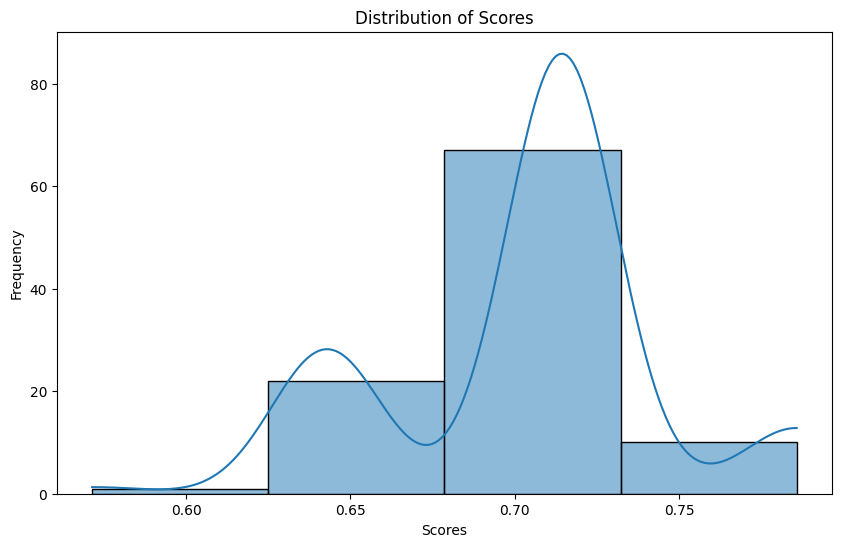

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(processed_scores, bins=4, kde=True)
plt.title("Distribution of Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.show()

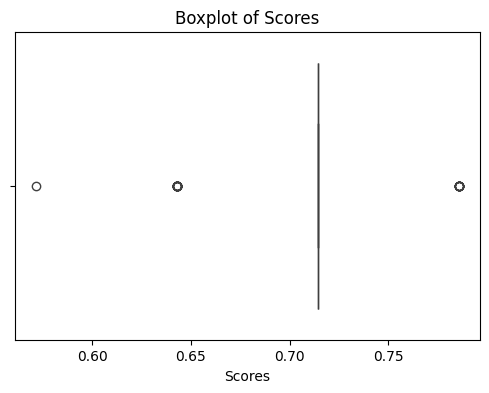

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=processed_scores)
plt.title("Boxplot of Scores")
plt.xlabel("Scores")
plt.show()

C:\Users\TasSp\AppData\Local\Temp\ipykernel_187684\1452912131.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(processed_scores, shade=True)


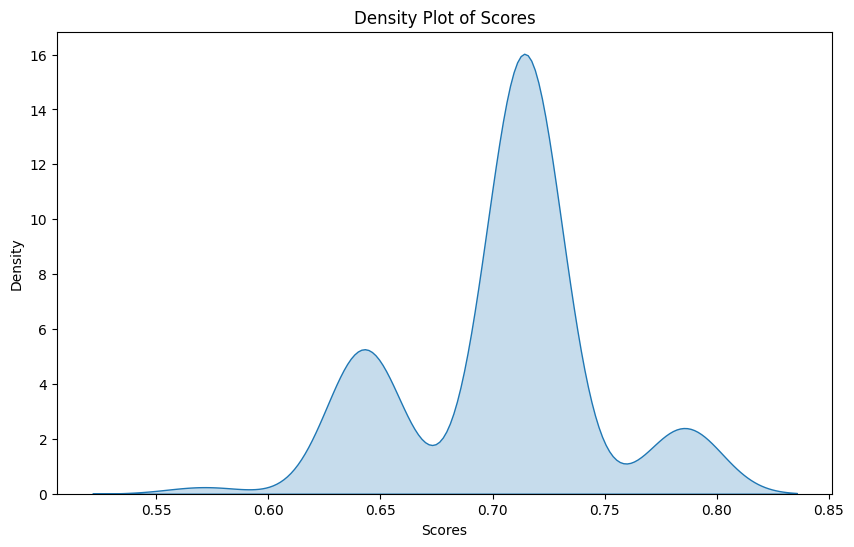

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(processed_scores, shade=True)
plt.title("Density Plot of Scores")
plt.xlabel("Scores")
plt.ylabel("Density")
plt.show()

### Experiment 3: Grading 100 Rewritten Versions of the Same Response (default temperature)

In [89]:
weave.init('ML Autograder-Grading(rewritten)') #

Logged in as Weights & Biases user: zgentile.
View Weave data at https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/weave


In [90]:
# Grading the 100 rewritten variations of the original response to measure consistency

num_trials = 100
experiment3_dataset = {"Submission Number": [],
                      "Submission": [],
                      "Unprocessed Scoring": [],
                      "Located Score": [],
                      "Processed Score": []}

for i in tqdm.tqdm(range(num_trials)):
    experiment3_dataset["Submission Number"].append(i)

    submission = rewritten_responses[i]
    experiment3_dataset["Submission"].append(submission)

    graded_response, call = grade_response.call(question, submission, clear_rubric)
    experiment3_dataset["Unprocessed Scoring"].append(graded_response)

    score = extract_llm_score(graded_response)
    experiment3_dataset["Located Score"].append(score)

    processed_score = compute_ratio(score)
    experiment3_dataset["Processed Score"].append(processed_score)

  0%|          | 0/100 [00:00<?, ?it/s]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f02d-15cd-7023-8dc0-24ed4844fd7b
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f02d-2c1c-75a2-abe0-6353938c864a


  1%|          | 1/100 [00:06<10:56,  6.63s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f02d-2fad-7443-b188-e41b46eda5d2
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f02d-3e47-77c2-a5fd-c9d74f55805f


  2%|▏         | 2/100 [00:11<08:46,  5.37s/it]

...

 98%|█████████▊| 98/100 [09:38<00:12,  6.12s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f035-eb2a-7520-916f-0a86a7ca27ba
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f036-0031-7e82-9bc2-cf709d476e8c


 99%|█████████▉| 99/100 [09:45<00:06,  6.19s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f036-03eb-7c51-b92c-eb8c80f38a92
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-rewritten/r/call/0195f036-11e1-7d13-8008-b8c03d626bcb


100%|██████████| 100/100 [09:49<00:00,  5.90s/it]


In [91]:
df2 = pd.DataFrame(experiment3_dataset)
df2

,Submission Number,Submission,Unprocessed Scoring,Located Score,Processed Score
0,0,One advantage of employing Enterprise Architec...,**Grade: 12/14 Points**\n\n**Explanation of th...,12/14,0.857143
1,1,One advantage of implementing an Enterprise Ar...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143
2,2,A key advantage of utilizing an Enterprise Arc...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143
3,3,One advantage of utilizing an Enterprise Archi...,Grade: 12/14\n\nReasoning:\n\n1. **Explanation...,12/14,0.857143
4,4,One advantage of implementing an Enterprise Ar...,**Grade: 12/14**\n\n**Reasoning:**\n\n1. **Exp...,12/14,0.857143
...,...,...,...,...,...
95,95,One advantage of utilizing an Enterprise Archi...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143
96,96,A key advantage of employing an Enterprise Arc...,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
97,97,One advantage of implementing an Enterprise Ar...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143
98,98,One advantage of implementing an Enterprise Ar...,**Grade: 12/14**\n\n**Explanation of the Benef...,12/14,0.857143


In [92]:
processed_scores = df2['Processed Score']
unique_counts = processed_scores.value_counts().sort_index()
print("Unique values and their counts:")
print(unique_counts)

Unique values and their counts:
Processed Score
0.714286     1
0.785714     1
0.857143    90
0.928571     5
1.000000     3
Name: count, dtype: int64


In [93]:
mean_val = processed_scores.mean()
variance_val = processed_scores.var()  # sample variance
std_dev_val = processed_scores.std()    # sample standard deviation

print("Mean:", mean_val)
print("Variance:", variance_val)
print("Standard Deviation:", std_dev_val)

Mean: 0.8628571428571429
Variance: 0.0011008039579468159
Standard Deviation: 0.033178365811878316


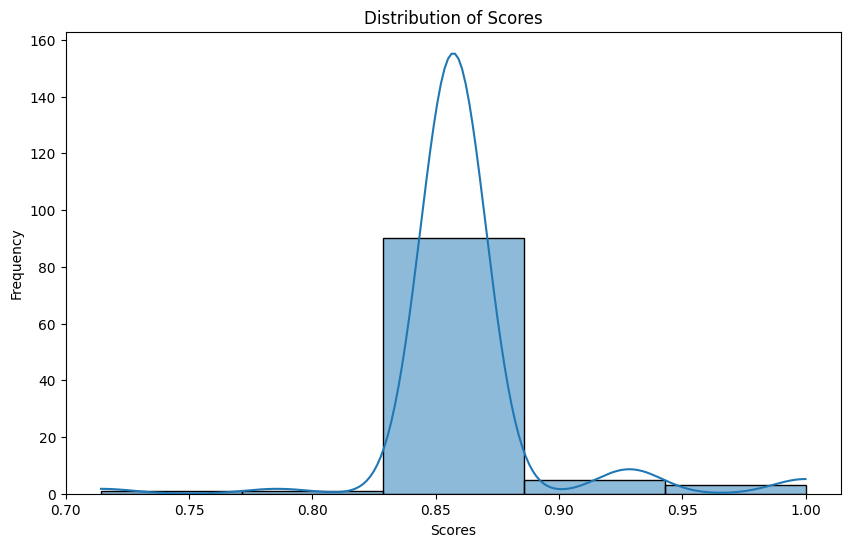

In [95]:
plt.figure(figsize=(10, 6))
sns.histplot(processed_scores, bins=5, kde=True)
plt.title("Distribution of Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.show()

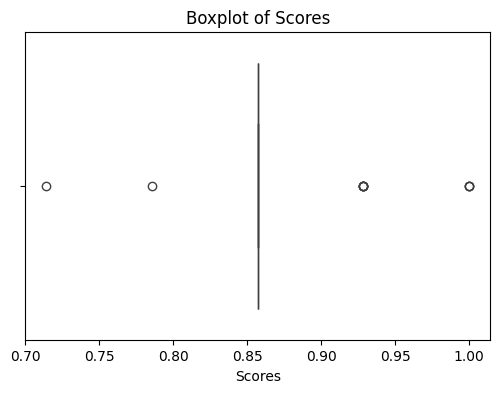

In [94]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=processed_scores)
plt.title("Boxplot of Scores")
plt.xlabel("Scores")
plt.show()

C:\Users\TasSp\AppData\Local\Temp\ipykernel_187684\1452912131.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(processed_scores, shade=True)


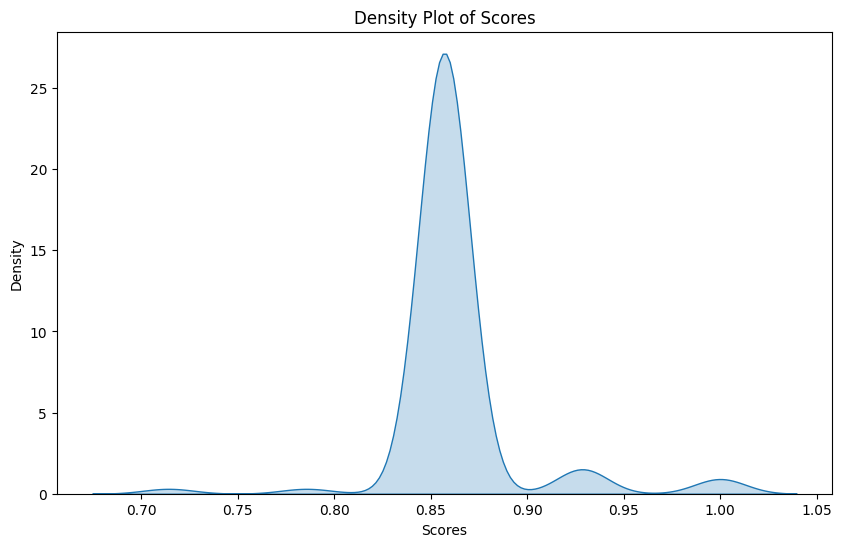

In [96]:
plt.figure(figsize=(10, 6))
sns.kdeplot(processed_scores, shade=True)
plt.title("Density Plot of Scores")
plt.xlabel("Scores")
plt.ylabel("Density")
plt.show()

### Experiment 4: Grading One Response 100 Times (low temperature)

In [97]:
weave.init('ML Autograder-Grading(original)')

Logged in as Weights & Biases user: zgentile.
View Weave data at https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/weave


In [98]:
# Grading the one response 100 times with the good rubric to measure consistency

num_trials = 100
experiment4_dataset = {"Trial Number": [],
                      "Unprocessed Scoring": [],
                      "Located Score": [],
                      "Processed Score": []}

submission = sentence # from previous section

for i in tqdm.tqdm(range(num_trials)):
    experiment4_dataset["Trial Number"].append(i)

    graded_response, call = grade_response.call(question, submission, clear_rubric, temp=.1)
    experiment4_dataset["Unprocessed Scoring"].append(graded_response)

    score = extract_llm_score(graded_response)
    experiment4_dataset["Located Score"].append(score)

    processed_score = compute_ratio(score)
    experiment4_dataset["Processed Score"].append(processed_score)

  0%|          | 0/100 [00:00<?, ?it/s]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f055-c385-7af1-b212-d745e5da6afd
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f055-d4c0-7761-889e-08d103a0172c


  1%|          | 1/100 [00:05<08:31,  5.17s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f055-d7af-7ac0-a895-c175f6ac7aa1
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f055-e7f6-7510-b05b-694823127c99


  2%|▏         | 2/100 [00:10<08:15,  5.06s/it]

...

 98%|█████████▊| 98/100 [08:58<00:12,  6.26s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f05d-fc4c-7613-a315-8cffe87d8b7e
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f05e-1009-7710-ab6c-be7ee5d592b0


 99%|█████████▉| 99/100 [09:04<00:06,  6.17s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f05e-1393-7ba2-a348-875e36953d60
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f05e-2373-77a0-b512-c9ec7937b078


100%|██████████| 100/100 [09:09<00:00,  5.50s/it]


In [99]:
df3 = pd.DataFrame(experiment4_dataset)
df

,Trial Number,Unprocessed Scoring,Located Score,Processed Score
0,0,**Grade: 11/14**\n\n**Explanation of the Benef...,11/14,0.785714
1,1,**Grade: 9/14**\n\n**Explanation of the Benefi...,9/14,0.642857
2,2,**Grade: 9/14**\n\n**Explanation of the Benefi...,9/14,0.642857
3,3,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
4,4,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
...,...,...,...,...
95,95,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
96,96,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
97,97,**Grade: 10/14**\n\n**Explanation of the Benef...,10/14,0.714286
98,98,### Grading:\n\n1. **Explanation of the Benefi...,11/14,0.785714


In [100]:
processed_scores = df3['Processed Score']
unique_counts = processed_scores.value_counts().sort_index()
print("Unique values and their counts:")
print(unique_counts)

Unique values and their counts:
Processed Score
0.642857     1
0.714286    99
Name: count, dtype: int64


In [101]:
mean_val = processed_scores.mean()
variance_val = processed_scores.var()  # sample variance
std_dev_val = processed_scores.std()    # sample standard deviation

print("Mean:", mean_val)
print("Variance:", variance_val)
print("Standard Deviation:", std_dev_val)

Mean: 0.7135714285714283
Variance: 5.102040816326527e-05
Standard Deviation: 0.00714285714285714


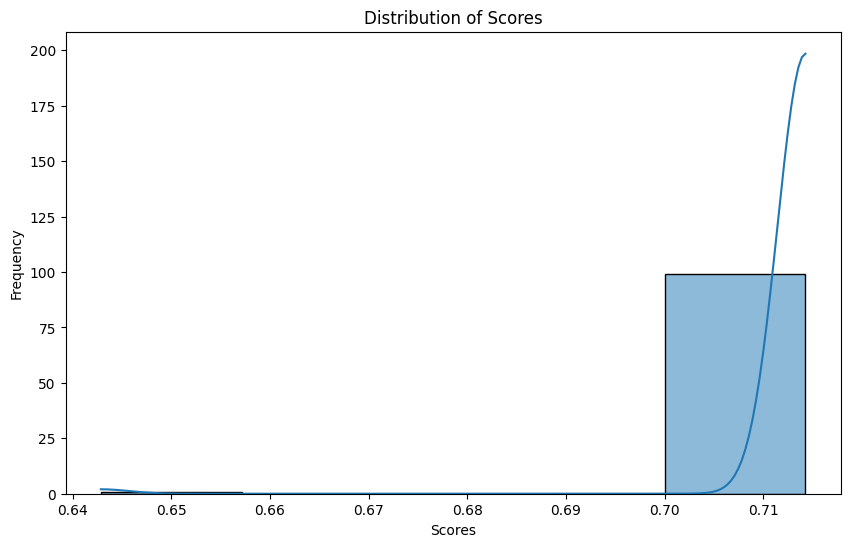

In [102]:
plt.figure(figsize=(10, 6))
sns.histplot(processed_scores, bins=5, kde=True)
plt.title("Distribution of Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.show()

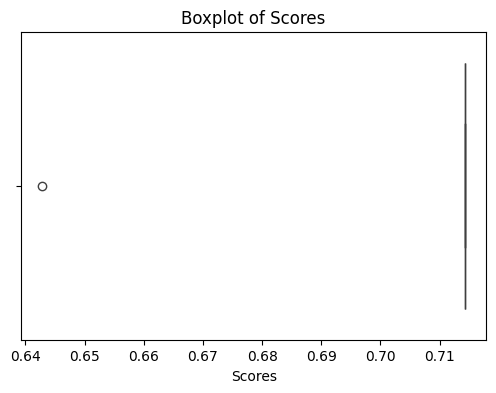

In [103]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=processed_scores)
plt.title("Boxplot of Scores")
plt.xlabel("Scores")
plt.show()

C:\Users\TasSp\AppData\Local\Temp\ipykernel_187684\1452912131.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(processed_scores, shade=True)


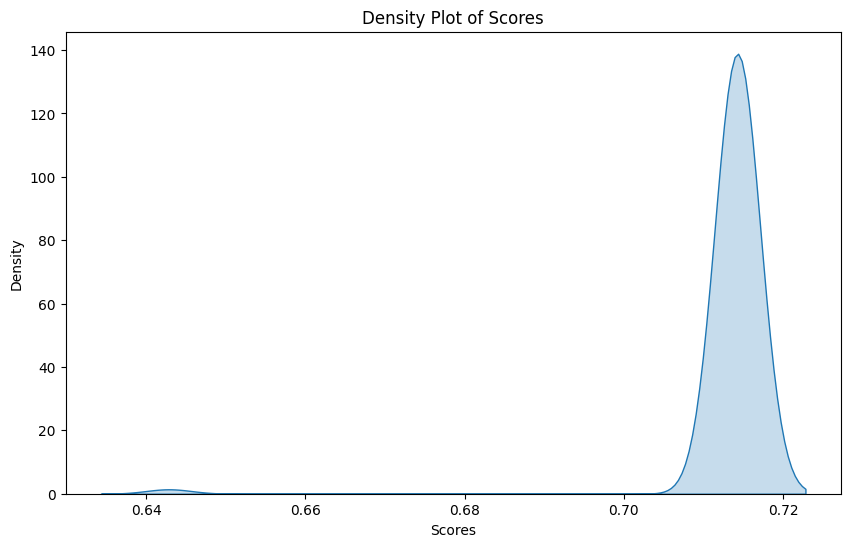

In [104]:
plt.figure(figsize=(10, 6))
sns.kdeplot(processed_scores, shade=True)
plt.title("Density Plot of Scores")
plt.xlabel("Scores")
plt.ylabel("Density")
plt.show()

### Experiment 5: Grading the Same Response 100 Times (Bad Rubric, Default Temp)

In [105]:
weave.init('ML Autograder-Grading(original)')

Logged in as Weights & Biases user: zgentile.
View Weave data at https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/weave


In [106]:
# Grading the one response 100 times with the original unclear rubric to measure consistency

num_trials = 100
experiment5_dataset = {"Trial Number": [],
                      "Unprocessed Scoring": [],
                      "Located Score": [],
                      "Processed Score": []}

submission = sentence # from previous section

for i in tqdm.tqdm(range(num_trials)):
    experiment5_dataset["Trial Number"].append(i)

    graded_response, call = grade_response.call(question, submission, unclear_rubric)
    experiment5_dataset["Unprocessed Scoring"].append(graded_response)

    score = extract_llm_score(graded_response)
    experiment5_dataset["Located Score"].append(score)

    processed_score = compute_ratio(score)
    experiment5_dataset["Processed Score"].append(processed_score)

  0%|          | 0/100 [00:00<?, ?it/s]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f061-12b7-7132-9b4e-4faf13167ee2
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f061-232f-7b31-abd5-8e22b2fa65ea


  1%|          | 1/100 [00:05<08:29,  5.14s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f061-26d1-7db0-bebd-bd43861d2df9
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f061-339c-7f02-a3ff-0d1781d6b5d5


  2%|▏         | 2/100 [00:09<07:25,  4.55s/it]

...

 98%|█████████▊| 98/100 [07:40<00:08,  4.09s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f068-18cf-7f52-b8b6-c326e79061d0
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f068-23fb-7241-b0ef-5d11b586d080


 99%|█████████▉| 99/100 [07:44<00:03,  3.97s/it]

🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f068-273d-7883-9ebe-daafe7266e1f
🍩 https://wandb.ai/zgentile-boston-university/ml-autograder-grading-original/r/call/0195f068-360d-7970-b60f-4f5ecf7f095a


100%|██████████| 100/100 [07:48<00:00,  4.69s/it]


In [109]:
df4 = pd.DataFrame(experiment5_dataset)
df4

,Trial Number,Unprocessed Scoring,Located Score,Processed Score
0,0,Grade: 14/14\n\nReasoning: The student's respo...,14/14,1.0
1,1,Grade: 14/14\n\nReasoning: The student's respo...,14/14,1.0
2,2,Grade: 14/14\n\nReasoning: The student's respo...,14/14,1.0
3,3,Grade: 14/14\n\nReasoning: The student's respo...,14/14,1.0
4,4,Grade: 14/14\n\nReasoning: The student's respo...,14/14,1.0
...,...,...,...,...
95,95,Grade: 14/14\n\nReasoning: The student's respo...,14/14,1.0
96,96,Grade: 14/14\n\nReasoning: The response provid...,14/14,1.0
97,97,Grade: 14/14\n\nReasoning: The student's respo...,14/14,1.0
98,98,Grade: 14/14\n\nReasoning: The student's respo...,14/14,1.0


In [108]:
processed_scores = df4['Processed Score']
unique_counts = processed_scores.value_counts().sort_index()
print("Unique values and their counts:")
print(unique_counts)

Unique values and their counts:
Processed Score
1.0    100
Name: count, dtype: int64


In [110]:
mean_val = processed_scores.mean()
variance_val = processed_scores.var()  # sample variance
std_dev_val = processed_scores.std()    # sample standard deviation

print("Mean:", mean_val)
print("Variance:", variance_val)
print("Standard Deviation:", std_dev_val)

Mean: 1.0
Variance: 0.0
Standard Deviation: 0.0


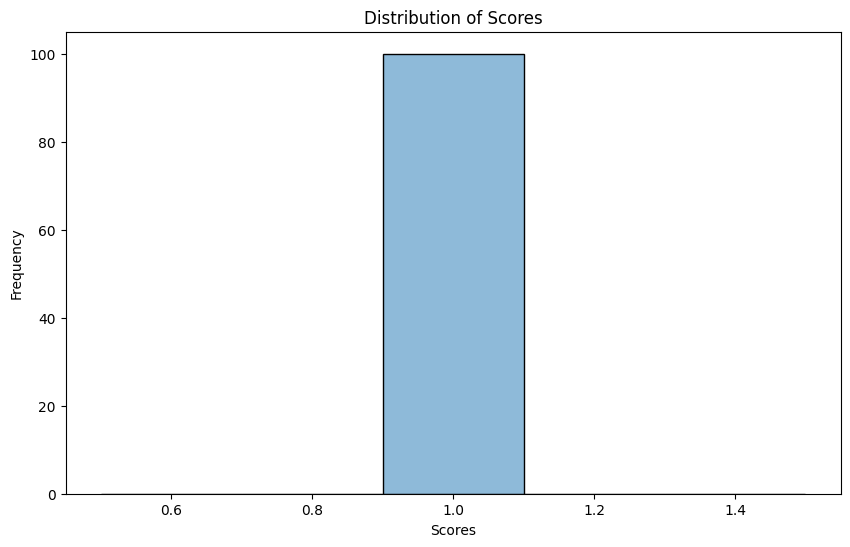

In [111]:
plt.figure(figsize=(10, 6))
sns.histplot(processed_scores, bins=5, kde=True)
plt.title("Distribution of Scores")
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.show()

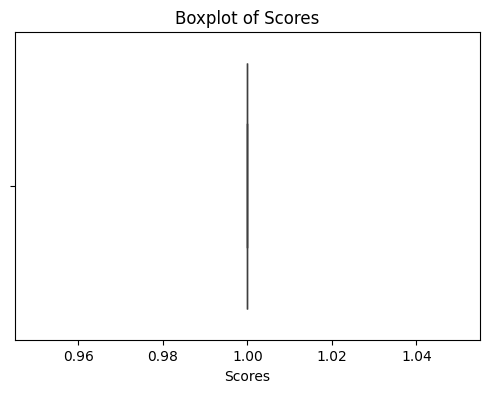

In [112]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=processed_scores)
plt.title("Boxplot of Scores")
plt.xlabel("Scores")
plt.show()

C:\Users\TasSp\AppData\Local\Temp\ipykernel_187684\1452912131.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(processed_scores, shade=True)
C:\Users\TasSp\AppData\Local\Temp\ipykernel_187684\1452912131.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(processed_scores, shade=True)


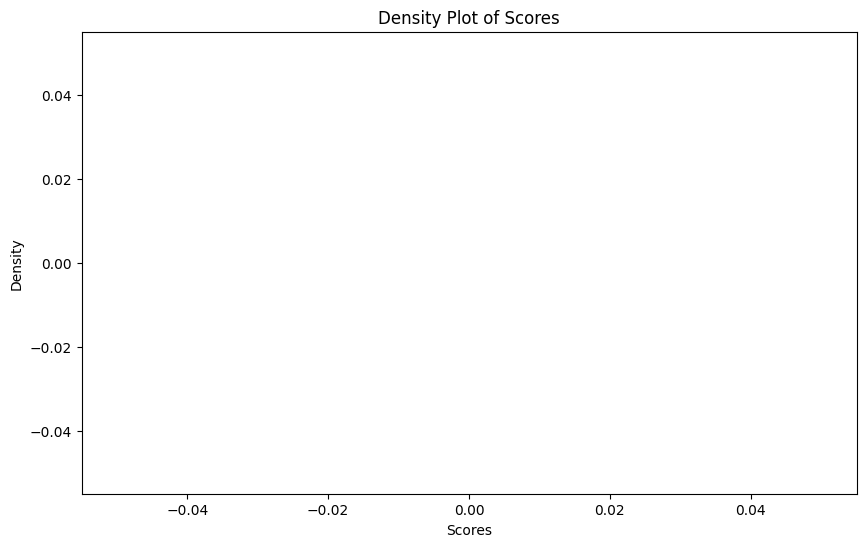

In [113]:
plt.figure(figsize=(10, 6))
sns.kdeplot(processed_scores, shade=True)
plt.title("Density Plot of Scores")
plt.xlabel("Scores")
plt.ylabel("Density")
plt.show()

While it may seem encouraging that there is completely consistent results, this is misleading. The LLM has very unclear guidance on how to grade and so it just gives full points every time, while in reality this submission had a score of 12/14.

Ingested Quiz 2 to showcase Prompt Enginnering techniques

In [ ]:
excel = pd.read_excel(r'G:\My Drive\met_data\Quiz_2\24fallmetcs581_m1 Quiz 2.xlsx', sheet_name=None)
for sheet_name, df_sheet in excel.items():
    var_name = f"df_{sheet_name.replace(' ', '_')}"
    globals()[var_name] = df_sheet
    print(f"Assigned DataFrame to: {var_name}")


Assigned DataFrame to: df_Question_Details
Assigned DataFrame to: df_Student_Submissions


In [159]:
df_Student_Quiz_Responses = pd.read_excel(r'G:\My Drive\met_data\Quiz_2\24fallmetcs581_m1 Quiz 2.xlsx', sheet_name='Student Submissions')

In [160]:


#Convert the dates to the score, as it is meant to be in a score
def convert_datetime_to_score(datetime_str):
    return f"{int(datetime_str[5:7])}/{int(datetime_str[8:10])}" if datetime_str.startswith("2025") else datetime_str



In [161]:
df_Student_Quiz_Responses['question 11 score'] = df_Student_Quiz_Responses['question 11 score'].astype(str)
df_Student_Quiz_Responses['question 11 score'] = df_Student_Quiz_Responses['question 11 score'].str.replace(' ', '')
df_Student_Quiz_Responses['question 11 score'] = df_Student_Quiz_Responses['question 11 score'].apply(lambda x: convert_datetime_to_score(x).strip())

In [162]:
df_Student_Quiz_Responses

,Unnamed: 0,question 11 answer,question 11 score,question 11 feedback,question 12 answer,question 12 score,question 12 feedback,additional feedback
0,Student 1,claims management is one of the functionalitie...,14/15,You highlighted how claims management improves...,privacy and security is always a challenge whe...,2025-12-15 00:00:00,"Your statement of ""Hacking and breaching of da...",NaN
1,Student 2,One of the challenges for an HIS/EHR to suppor...,15/15,Excellent work identifying a key challenge and...,One function of a revenue cycle management sys...,15/15,Nice work!,NaN
...,...,...,...,...,...,...,...,...
20,Student 21,Revenue cycle management (RCM) is the process ...,14/15,Good work! I can't seem to find the article th...,One challenge for a Health Information System ...,13/15,Your response effectively outlines how the int...,NaN
21,Student 22,Some of the challenges to supporting populatio...,13/15,Your response highlights relevant challenges s...,Proper coding can greatly increase the revenue...,15/15,NaN,NaN


Let's scale the leniency of the model

First from 1 to 5 in terms of leniency to strictness, we begin observing to see if the model will grade based on that parameter. First, we will begin experimenting it with the quiz 2 responses, specifically question, and we will be given a course material, which is sample answer rubric
CS581 2025 Spring 1 Quiz 2 (Pop Health & RCM) Short Answer Grading Rubric

First let's try level 1, which is lenient

# Level 1 Leniency Grading

In [163]:
def grade_student_response(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)

    # Create the grading prompt
    grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 1 (Lenient)
You will grade the student's response with **a lenient approach**, focusing on encouraging learning rather than strict adherence to the material. This means:
- **Partial credit is given** even if the answer is incomplete but demonstrates understanding.
- **Minor mistakes** (e.g., wording, slight misinterpretations) are overlooked if the core idea is correct.
- **Constructive feedback is prioritized** over penalties, helping students refine their knowledge.

### Grading Criteria:
- **A score out of 15** reflecting the quality and completeness of the response.
- **Detailed feedback** for each criterion, emphasizing strengths and areas for improvement.
- **Gentle suggestions** for enhancement, guiding students toward better understanding.
- **Relevant supporting material** from the course content to justify feedback.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""

    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)


In [164]:
COURSE_MATERIAL = r"G:\My Drive\met_data\Quiz_2\CS581 2025 Spring 1 Quiz 2 (Pop Health & RCM) Short Answer Grading Rubric.docx"
# Grade each answer in the DataFrame
df_Student_Quiz_Responses["question 11 grade"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response(COURSE_MATERIAL, answer)
)


In [165]:
print(df_Student_Quiz_Responses["question 11 grade"])

0     ### Score: 13/15\n\n### Feedback:\n\n#### Iden...
1     ### Evaluation\n\n**Score: 13/15**\n\n---\n\n#...
                            ...                        
20    ### Score: 15/15\n\n### Feedback:\n\n#### Iden...
21    ### Score: 13/15\n\n### Feedback:\n\n**Identif...
Name: question 11 grade, Length: 22, dtype: object


# Let's parse the grades from the AI text to

In [166]:
#extract scores from the text
def extract_score(text):
    score = re.search(r"Score: (\d{1,2}/15)", text)
    if score:
        return score.group(1)
    return None

# Apply the function to each row in the 'question grade' column
df_Student_Quiz_Responses['AI Q11 grade lvl 1'] = df_Student_Quiz_Responses['question 11 grade'].apply(extract_score)

In [167]:
df_Student_Quiz_Responses

,Unnamed: 0,question 11 answer,question 11 score,question 11 feedback,question 12 answer,question 12 score,question 12 feedback,additional feedback,question 11 grade,AI Q11 grade lvl 1
0,Student 1,claims management is one of the functionalitie...,14/15,You highlighted how claims management improves...,privacy and security is always a challenge whe...,2025-12-15 00:00:00,"Your statement of ""Hacking and breaching of da...",NaN,### Score: 13/15\n\n### Feedback:\n\n#### Iden...,13/15
1,Student 2,One of the challenges for an HIS/EHR to suppor...,15/15,Excellent work identifying a key challenge and...,One function of a revenue cycle management sys...,15/15,Nice work!,NaN,### Evaluation\n\n**Score: 13/15**\n\n---\n\n#...,13/15
...,...,...,...,...,...,...,...,...,...,...
20,Student 21,Revenue cycle management (RCM) is the process ...,14/15,Good work! I can't seem to find the article th...,One challenge for a Health Information System ...,13/15,Your response effectively outlines how the int...,NaN,### Score: 15/15\n\n### Feedback:\n\n#### Iden...,15/15
21,Student 22,Some of the challenges to supporting populatio...,13/15,Your response highlights relevant challenges s...,Proper coding can greatly increase the revenue...,15/15,NaN,NaN,### Score: 13/15\n\n### Feedback:\n\n**Identif...,13/15


## Let's visualize it!

First we check the distribution of grades for question 11 that were graded by the CA/TA

C:\Users\MHS\AppData\Local\Temp\ipykernel_25116\587413939.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


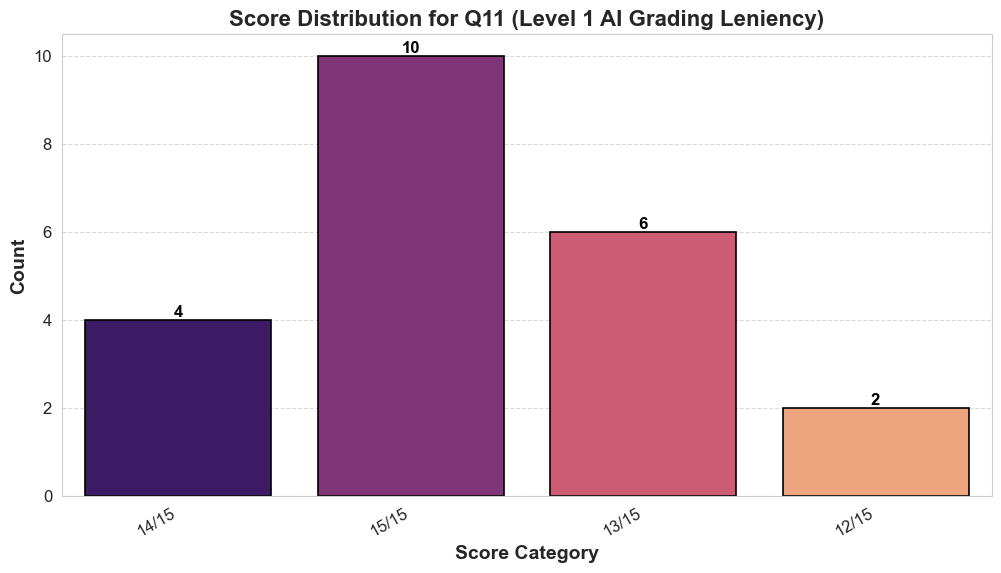

In [203]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses,
    x='question 11 score',
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 1 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


## Count Plot for Score Distribution for Q11 (Level 1 Leniency)

C:\Users\MHS\AppData\Local\Temp\ipykernel_25116\2721957284.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


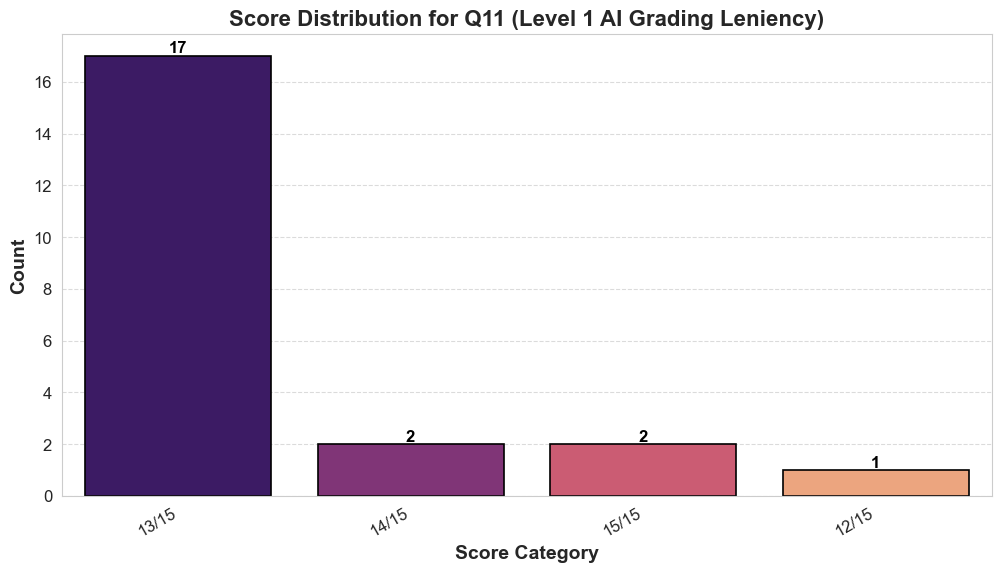

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses,
    x='AI Q11 grade lvl 1',
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 1 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


It was somewhat the same distribution as the CA/TA grading, mainly where a total of 22 students, 17 students had a 13/15 based on the rubric from the ai model, whereas 10 students had a 15/15, which were graded by CA/TA. We can check an overlay histogram to compare distribution between two grades

## Overlay Histogram to compare the distribution of the TA/CA grade to the AI grade of leniency level 1 (Lenient)

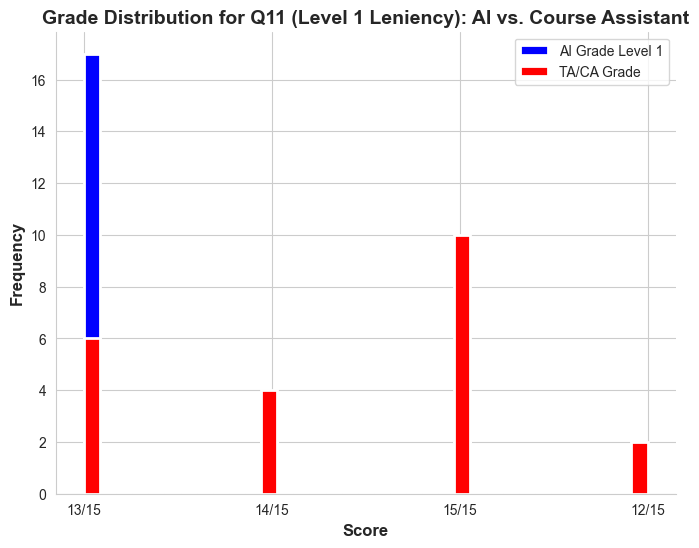

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(8, 6))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 1'], bins=35, linewidth=2, label='AI Grade Level 1', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='TA/CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 1 Leniency): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()


As stated, it seems the AI model is not as much lenient as the CA/TA, as most students received a 13/15 from AI model on leniency level of 1.

# Level 2 Leniency Grading



In [173]:
def grade_student_response_lvl2(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)

    # Create the grading prompt
    grading_prompt = grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 2 (Slightly Lenient)
You will grade the student's response with a **slightly lenient approach**, balancing encouragement with accuracy. This means:
- **Partial credit is still given**, but responses should show clear understanding.
- **Minor mistakes are considered**, but they should not significantly affect comprehension.
- **Constructive feedback is provided**, but with slightly stricter adherence to key concepts.

### Grading Criteria:
- **A score out of 15** reflecting the quality and completeness of the response.
- **Feedback for each criterion**, highlighting strengths and pinpointing areas for improvement.
- **More specific suggestions** to correct misunderstandings while still encouraging the student.
- **Relevant quotes** from the course material to justify feedback and guide learning.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""


    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)


In [ ]:
# Grade each answer in the DataFrame with Level 2 leniency
df_Student_Quiz_Responses["question 11 grade lvl 2"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response_lvl2(COURSE_MATERIAL, answer))

In [176]:
#extract scores from the text
def extract_score(text):
    score = re.search(r"Score: (\d{1,2}/15)", text)
    if score:
        return score.group(1)
    return None

# Apply the function to each row in the 'question grade' column
df_Student_Quiz_Responses['AI Q11 grade lvl 2'] = df_Student_Quiz_Responses['question 11 grade lvl 2'].apply(extract_score)

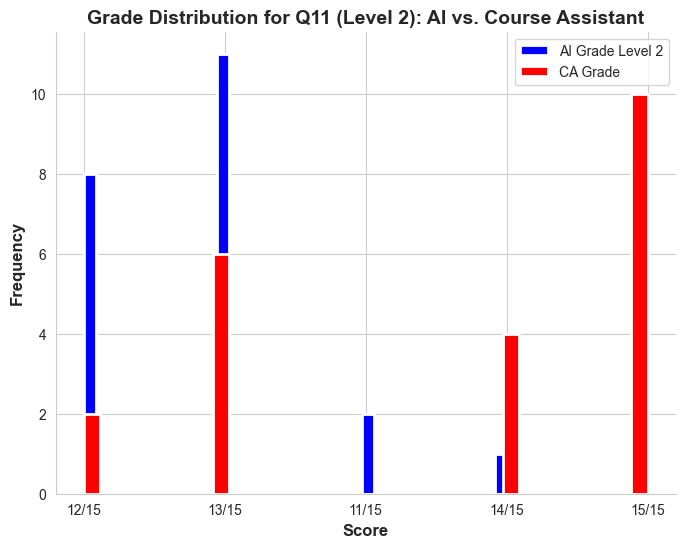

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(8, 6))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 2'], bins=35, linewidth=2, label='AI Grade Level 2', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 2): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()


We see that the model actually gave a 11/15 score to two anonymized students based on the quiz rubric. Compared to the TA/CA grading, where none of them gave a low score like the AI did.

C:\Users\MHS\AppData\Local\Temp\ipykernel_25116\790910345.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


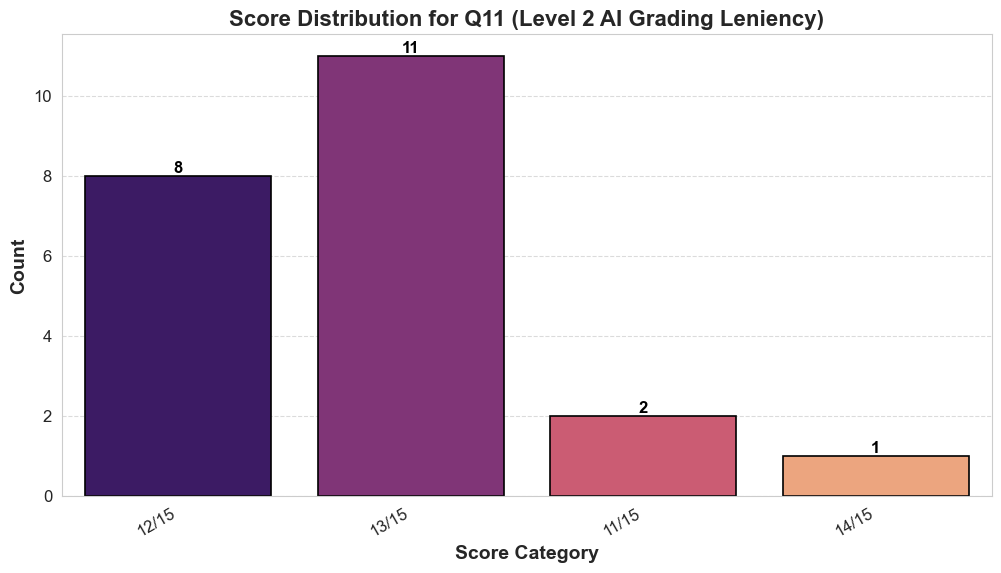

In [178]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses,
    x='AI Q11 grade lvl 2',
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 2 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


Now we are beginning to see students getting scores of 11/15 indicating that the AI was moderately lenient, avoiding extreme high or low scores. The majority of students scored 13/15, with 11 students receiving this score.

# Level 3 Leniency Grading

Now let's try level three leniency grading

In [180]:
def grade_student_response_lvl3(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)

    # Create the grading prompt
    grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 3 (Moderately Strict)
You will grade the student's response with a **moderately strict approach**, emphasizing accuracy and correctness. This means:
- **Partial credit** is still given, but responses must clearly demonstrate understanding of the core concepts.
- **Mistakes are noted and addressed** more thoroughly, and the student’s response must adhere more closely to the material.
- **Feedback is constructive but direct**, focusing on areas where the student needs improvement with specific recommendations for correction.

### Grading Criteria:
- **A score out of 15** reflecting the quality and completeness of the response, with a stronger emphasis on correctness.
- **Direct feedback for each criterion**, pointing out mistakes clearly and offering suggestions to correct misunderstandings.
- **Specific references** to the course material are provided to ensure the student knows where they went wrong and how to improve.
- **Concise but firm suggestions** for how to enhance the response, with less emphasis on encouragement compared to leniency levels 1 and 2.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""

    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)


In [181]:
df_Student_Quiz_Responses["question 11 grade lvl 3"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response_lvl3(COURSE_MATERIAL, answer))

In [182]:
df_Student_Quiz_Responses['AI Q11 grade lvl 3'] = df_Student_Quiz_Responses['question 11 grade lvl 3'].apply(extract_score)

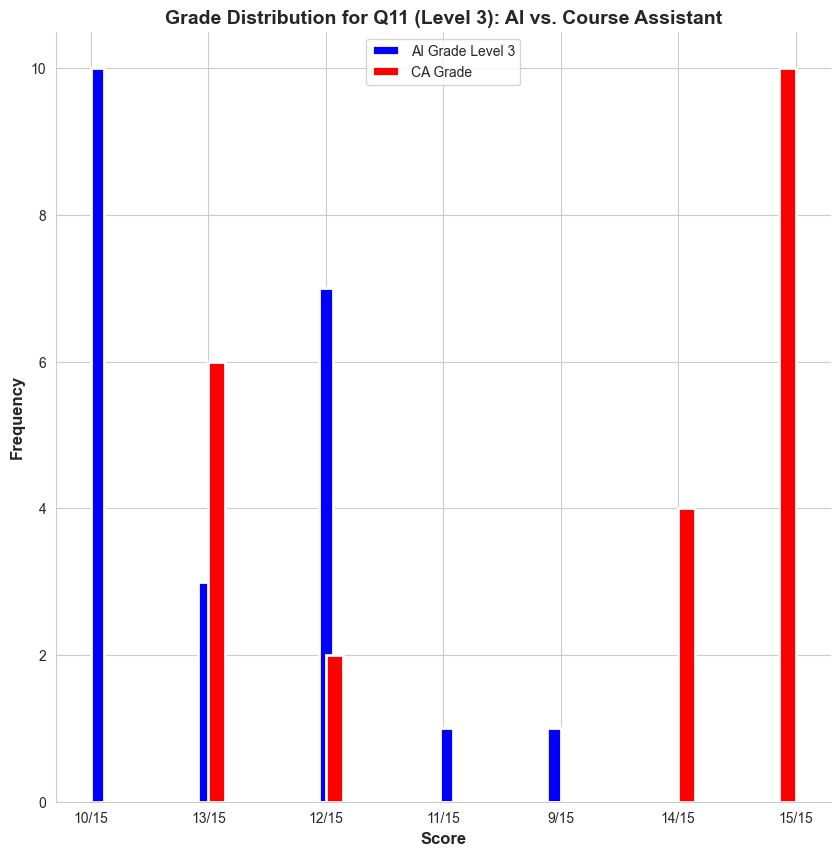

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(10, 10))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 3'], bins=35, linewidth=2, label='AI Grade Level 3', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 3): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()



Now we notice some somewhat average scores of 10/15 from ten students in class, much lower than the previous test

C:\Users\MHS\AppData\Local\Temp\ipykernel_25116\2661637868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


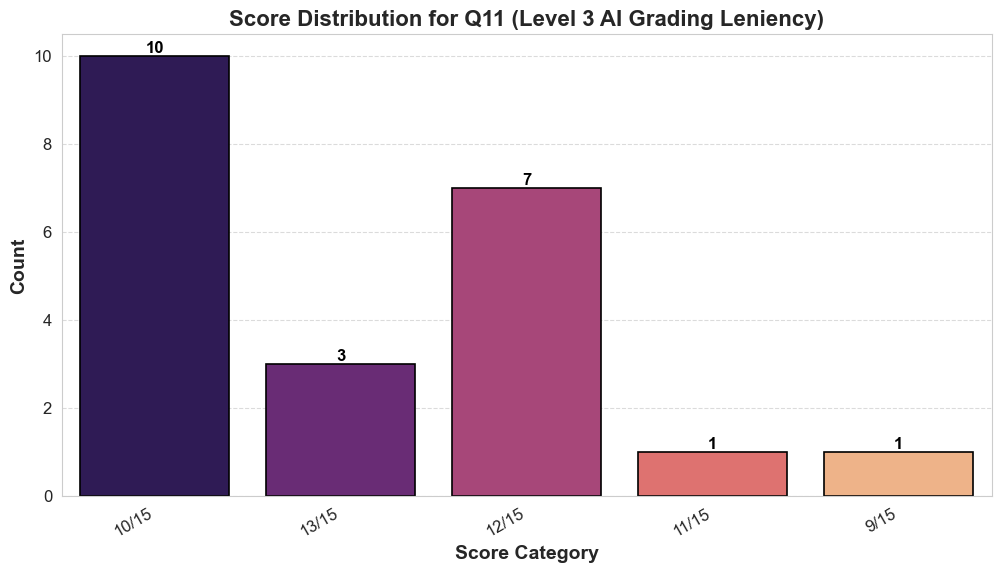

In [185]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses,
    x='AI Q11 grade lvl 3',
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 3 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


# Level 4 Grading Leniency

In [186]:
def grade_student_response_lvl4(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)

    # Create the grading prompt
    grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 4 (Strict)
You will grade the student's response with a **strict approach**, prioritizing accuracy, completeness, and adherence to the provided material. This means:
- **Partial credit is limited**, and responses must closely follow the course material.
- **Mistakes are thoroughly analyzed**, and even minor errors will result in deductions.
- **Feedback is firm and precise**, clearly identifying incorrect statements and gaps in understanding.
- **Higher expectations for completeness**—responses should cover all necessary details without vague or unsupported claims.

### Grading Criteria:
- **A score out of 15** with a strong emphasis on correctness and full alignment with the course material.
- **Thorough feedback for each criterion**, explicitly stating where the response falls short.
- **Exact references** to the course material, ensuring the student understands their mistakes.
- **Minimal leniency in grading**—responses must be well-structured, factually accurate, and demonstrate a deep understanding of the subject matter.
- **Strict but constructive recommendations** for improvement, guiding the student to meet high academic standards.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""


    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)


In [187]:
df_Student_Quiz_Responses["question 11 grade lvl 4"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response_lvl4(COURSE_MATERIAL, answer))

In [189]:
df_Student_Quiz_Responses['AI Q11 grade lvl 4'] = df_Student_Quiz_Responses['question 11 grade lvl 4'].apply(extract_score)

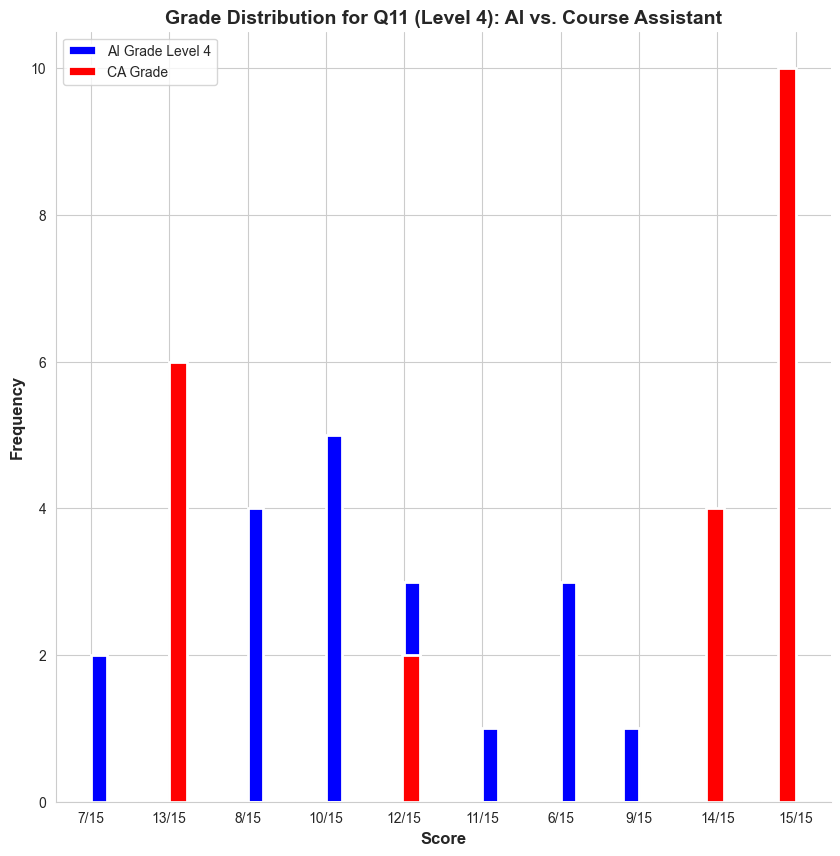

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(10, 10))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 4'], bins=35, linewidth=2, label='AI Grade Level 4', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 4): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()



C:\Users\MHS\AppData\Local\Temp\ipykernel_25116\371444310.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


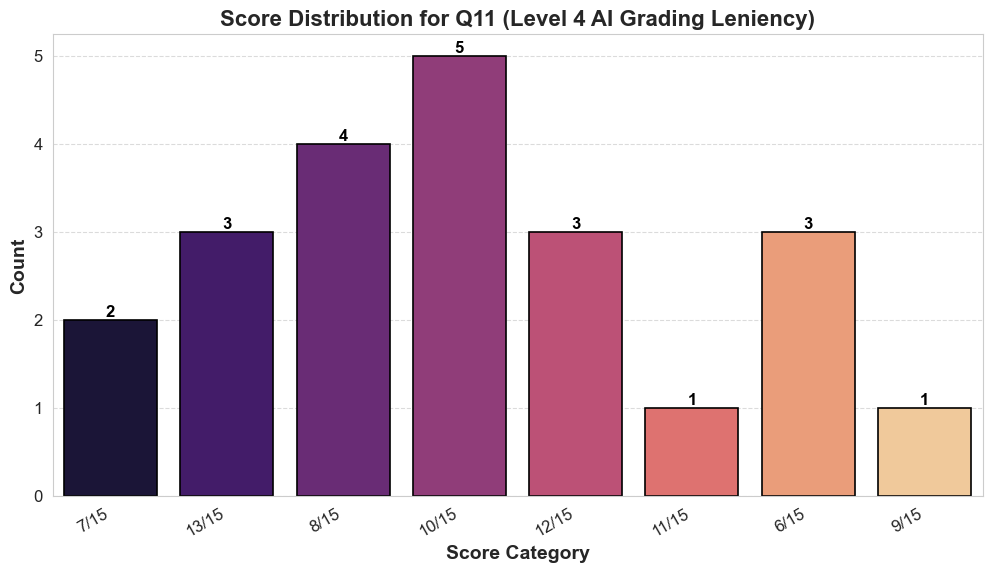

In [191]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses,
    x='AI Q11 grade lvl 4',
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 4 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


Now the AI model is beginning to strictly deduct student's for even minor errors based on the rubric. Now we will try our last level, which is just very strict grading

## Level 5 Grading Leniency

In [195]:
def grade_student_response_lvl5(course_material_path, student_response):
    # Encode the course material
    encoded_material = encode_file(course_material_path)

    # Create the grading prompt
    grading_prompt = f"""
You are an expert grading assistant. Your task is to evaluate a student's response against the provided course material.

### Grading Leniency Level: 5 (Very Strict)
You will grade the student's response with the **strictest possible approach**, requiring complete accuracy, depth, and direct alignment with the course material. This means:
- **No partial credit is given**—responses must be entirely correct and comprehensive.
- **Every mistake, even minor ones, results in a deduction** to ensure precision.
- **Feedback is firm and uncompromising**, directly pointing out any inaccuracies or omissions.
- **No room for vague, incomplete, or incorrect responses**—every statement must be supported by the course material.

### Grading Criteria:
- **A score out of 15**, with no leniency for partial understanding or minor errors.
- **In-depth feedback for each criterion**, identifying every error and explaining why it is incorrect.
- **Strict adherence to the course material**, requiring direct citations for every key concept.
- **Minimal subjective interpretation**—grading is purely based on factual correctness.
- **High expectations for structure, clarity, and precision**—responses must be well-organized and professionally written.

Course Material Content (from attached file):
[The system will have access to the attached course material]

Student Response:
{student_response}
"""


    response = openai_chat_client.responses.create(
        model="gpt-4o",
        input=[
            {
                "role": "system",
                "content": [
                    {
                        "type": "input_text",
                        "text": grading_prompt
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": os.path.basename(course_material_path),
                        "file_data": f"data:application/pdf;base64,{encoded_material}"
                    }
                ]
            }
        ],
        text={"format": {"type": "text"}},
        reasoning={},
        tools=[],
        temperature=0.3,  # Lower temperature for more consistent grading
        max_output_tokens=2000,
        top_p=0.9,
        store=True
    )
    return (response.output[0].content[0].text)



In [196]:

df_Student_Quiz_Responses["question 11 grade lvl 5"] = df_Student_Quiz_Responses["question 11 answer"].apply(
    lambda answer: grade_student_response_lvl5(COURSE_MATERIAL, answer))

In [197]:
df_Student_Quiz_Responses['AI Q11 grade lvl 5'] = df_Student_Quiz_Responses['question 11 grade lvl 5'].apply(extract_score)

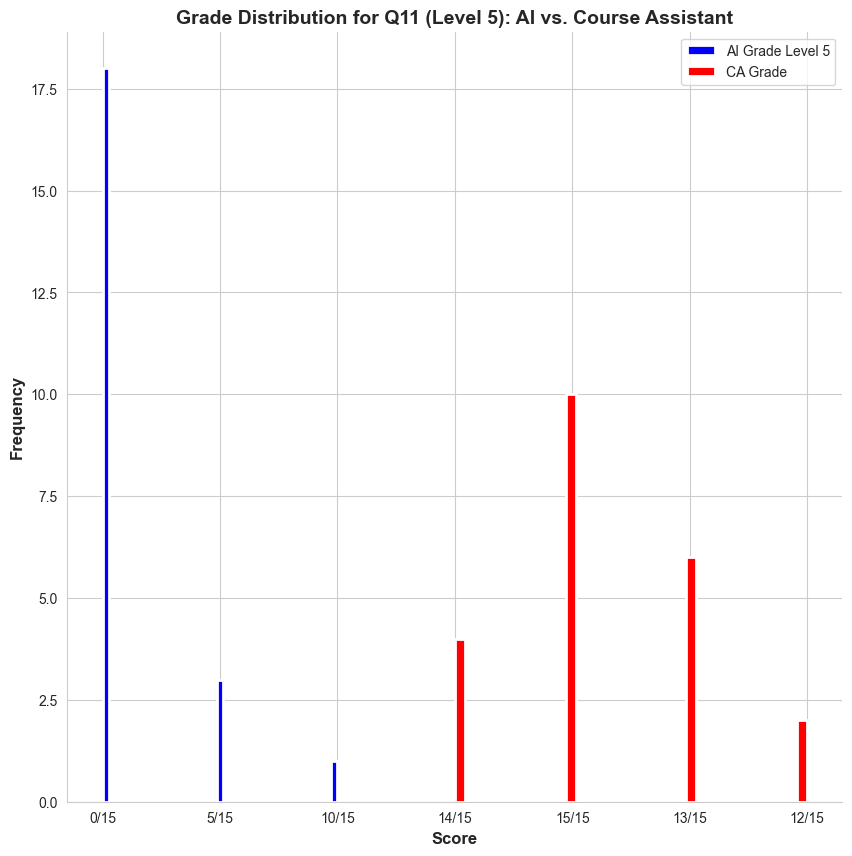

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set_style("whitegrid")

# Create the step histograms
plt.figure(figsize=(10, 10))
plt.hist(df_Student_Quiz_Responses['AI Q11 grade lvl 5'], bins=35, linewidth=2, label='AI Grade Level 5', color='blue')
plt.hist(df_Student_Quiz_Responses['question 11 score'], bins=35,  linewidth=2, label='CA Grade', color='red')

# Labels and title improvements
plt.xlabel('Score', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Grade Distribution for Q11 (Level 5): AI vs. Course Assistant', fontsize=14, fontweight='bold')

# Improve legend
plt.legend(frameon=True, fontsize=10)

# Remove unnecessary spines
sns.despine()

# Show the plot
plt.show()



C:\Users\MHS\AppData\Local\Temp\ipykernel_25116\2199518732.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


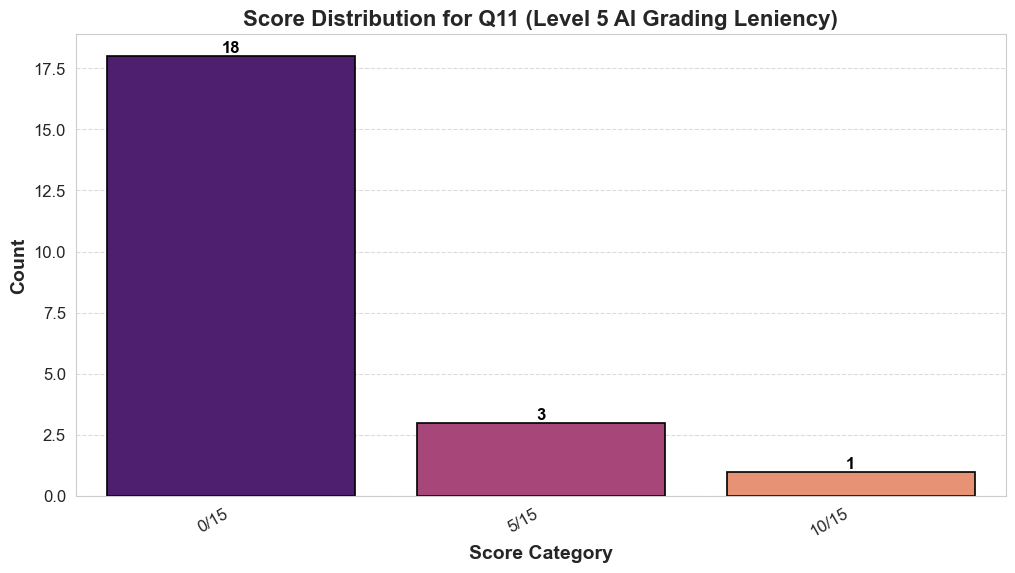

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern style
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

# Create the count plot with enhanced aesthetics
ax = sns.countplot(
    data=df_Student_Quiz_Responses,
    x='AI Q11 grade lvl 5',
    palette='magma',  # A more visually appealing color palette
    edgecolor='black',  # Adds black edges to bars for better visibility
    linewidth=1.2
)

# Add labels to bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Score Category", fontsize=14, fontweight='bold')
plt.ylabel("Count", fontsize=14, fontweight='bold')
plt.title("Score Distribution for Q11 (Level 5 AI Grading Leniency)", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add a subtle grid for better readability
plt.grid(axis='y', linestyle="--", alpha=0.7)

# Show the plot
plt.show()


In [201]:
df_Student_Quiz_Responses.head()

,Unnamed: 0,question 11 answer,question 11 score,question 11 feedback,question 12 answer,...,AI Q11 grade lvl 3,question 11 grade lvl 4,AI Q11 grade lvl 4,question 11 grade lvl 5,AI Q11 grade lvl 5
0,Student 1,claims management is one of the functionalitie...,14/15,You highlighted how claims management improves...,privacy and security is always a challenge whe...,...,10/15,### Evaluation of Student Response\n\n**Score:...,7/15,**Score: 0/15**\n\nThe student's response fail...,0/15
1,Student 2,One of the challenges for an HIS/EHR to suppor...,15/15,Excellent work identifying a key challenge and...,One function of a revenue cycle management sys...,...,13/15,"### Evaluation\n\n**Student Response:**\n\n""On...",13/15,### Evaluation of Student Response\n\n**Studen...,0/15
2,Student 3,Claims management is a vital component of a re...,15/15,Nice work!,Data interoperability is a major obstacle for ...,...,10/15,### Evaluation of Student Response\n\n**Score:...,8/15,**Score: 0/15**\n\n**Feedback:**\n\n1. **Ident...,0/15
3,Student 4,One of the main challenges for an HIS/EHR to e...,15/15,Great work!,One function of a revenue cycle management sys...,...,12/15,### Evaluation of Student Response\n\n**Score:...,10/15,### Evaluation of Student Response\n\n**Score:...,0/15
4,Student 5,A vital function of a revenue cycle management...,15/15,Excellent work! \n\n\n\n\nReminder if you use ...,One significant challenge for a Health Informa...,...,12/15,## Evaluation of Student Response\n\n### Score...,8/15,### Evaluation of Student Response\n\n**Score:...,0/15
